In [1]:
import operator
import random
import pandas as pd
import numpy as np
from sklearn import tree
from deap import gp
from gp.deap_gp import setup_pset
from gp.gp_generalise import infer_output
from gp.gp_generalise import infer_guard
import matplotlib.pyplot as plt
from gp import deap_gp


In [125]:
#Functions to generate input samples, functions, output, and to infer with GP


def create_input_samples(numInputParameters, parameterRange=(0, 100), distinctInputSet=None, tableLength=10, random_seed=42):
    np.random.seed(random_seed)
    if distinctInputSet:
        df = pd.DataFrame()
        for i in range(numInputParameters):
            df[f'i{i}']=np.random.choice(distinctInputSet, size=tableLength)
            reg = np.zeros_like(df[f'i{i}'])
            reg[0] = np.random.choice(distinctInputSet)
            reg[1:] = df[f'i{i}'][:-1].values
            df[f'r{i}'] = reg 
    else:
        df = pd.DataFrame()
        for i in range(numInputParameters):
            if i == 0:
                df[f'i{i}'] = np.random.randint(-10, 10, size=tableLength)
            else:
                df[f'i{i}']=np.random.randint(*parameterRange, size=tableLength)
            reg = np.zeros_like(df[f'i{i}'])
            reg[0] = np.random.randint(*parameterRange)
            reg[1:] = df[f'i{i}'][:-1].values
            df[f'r{i}'] = reg
    df = df[[c for c in df.columns if c.startswith('i')] + [c for c in df.columns if c.startswith('r')]]
    return df

def get_true_function_output(trueFunction, df):
    # build a pset with a dummy output column so arg names are renamed to df columns
    # add an output register to the dataframe 
    regs = df.columns.tolist()
    regs = [r for r in regs if r.startswith('r')]
    regsnums = [int(r[1:]) for r in regs]
    max_reg_num = max(regsnums) if regsnums else -1
    df[f'r{max_reg_num + 1}'] = np.zeros((len(df),), dtype=int)
    #add randomvalue to the first row of the output register to ensure it's not all zeros if the true function uses it
    df.at[0, f'r{max_reg_num + 1}'] = np.random.randint(1,100)

    # compile the true function and apply it to the dataframe to get the output column

    df['o'] = np.zeros_like(df[f'r{max_reg_num + 1}'])
    pset = deap_gp.setup_pset(df)
    tree = gp.PrimitiveTree.from_string(trueFunction, pset)
    trueFunctionCompiled = gp.compile(tree, pset)
    if f'r{max_reg_num + 1}' not in trueFunction:
        df['o'] = df.drop(columns='o').apply(lambda row: trueFunctionCompiled(**row.to_dict()), axis=1)
        df.loc[1:, f'r{max_reg_num + 1}'] = df['o'][:-1].values
    else:
        for idx in df.index:
            if idx > 0:
                df.at[idx, f'r{max_reg_num + 1}'] = df.at[idx-1, 'o']
            row = df.loc[idx, df.drop(columns='o').columns]   
            df.at[idx, 'o'] = trueFunctionCompiled(**row.to_dict())
    
    # reorder columns to have inputs, then registers, then output
    df = df[[c for c in df.columns if c.startswith('i')] + [c for c in df.columns if c.startswith('r')] + ['o']]
    return df

def get_true_guard_output(trueGuard, df):
    df['target'] = np.zeros((len(df),), dtype=bool)
    pset = deap_gp.setup_pset(df)
    tree = gp.PrimitiveTree.from_string(trueGuard, pset)
    trueGuardCompiled = gp.compile(tree, pset)
    df['target'] = df.drop(columns=['target']).apply(lambda row: trueGuardCompiled(**row.to_dict()), axis=1)
    print(df['target'].dtype)
    return df

def setFunction(parameters, complexity, constantProb=0.3, maxConstant=10):
    regs = parameters.copy()
    regs = [r for r in regs if r.startswith('r')]
    regsnums = [int(r[1:]) for r in regs]
    max_reg_num = max(regsnums) if regsnums else -1
    parameters.append(f'r{max_reg_num + 1}') # add output register as a parameter for the function to use
    ops = ['add', 'sub', 'mul']
    u = np.random.random_sample()
    if u < constantProb:
        param1 = str(np.random.randint(1, maxConstant + 1))
    else:
        param1 = np.random.choice(parameters)

    if complexity <= 1:
        if complexity == 0:
            ops = ['add', 'sub']
        else:
            parameters = [p for p in parameters if p != param1]
        param2 = np.random.choice(parameters)
        op = np.random.choice(ops)
        return op + "(" + param1 + "," + param2 + ")"
    else:
        parameters = [p for p in parameters if p != f'r{max_reg_num + 1}'] 
        func = setFunction(parameters, complexity-1, constantProb, maxConstant)
        op = np.random.choice(ops)
        return op + "(" + param1 + "," + func + ")"

def setFunctionLinear(parameters, depth, maxCoeff=10):
    ops = ['add', 'sub', 'mul']
    expr = ""
    while depth > 0:
        op = np.random.choice(ops)
        param = np.random.choice(parameters)
        if op == 'mul':
            coeff = np.random.randint(1, maxCoeff + 1)
            plusMinus = np.random.choice(['', '-'])
            newexpr = plusMinus + str(coeff) + "*" + param
        else:
            param1 = np.random.choice(parameters)
            param2 = np.random.choice(parameters)
            newexpr = param1 + op + param2
            depth -= 1
        if expr == "":
            expr = newexpr
        else:
            expr = expr + "+" + newexpr
    return expr

def setGuard(parameters, complexity, maxConstant=10):
    ops = ['lt', 'gt', 'le', 'ge', 'eq', 'ne']
    if complexity == 1:
        param1 = np.random.choice(parameters)
        op = np.random.choice(ops)
        if np.random.random_sample() < 0.5:
            parameters = [p for p in parameters if p != param1]
            param2 = np.random.choice(parameters)
        else:
            param2 = np.random.randint(0, maxConstant + 1)
        return f"{op}({param1}, {param2})"
    else:
        andor = np.random.choice(['and_', 'or_'])
        guard1 = setGuard(parameters, complexity-1, maxConstant)
        guard2 = setGuard(parameters, complexity-1, maxConstant)
        return f"({guard1} {andor} {guard2})"


def infer_w_gp(df, ngen=100, random_seed=42):
    tmp = df.drop(columns=['o']).copy()
    pset = deap_gp.setup_pset(df)
    inferredFuncStr = infer_output(df, ngen=ngen, random_seed=random_seed)
    tree = gp.PrimitiveTree.from_string(inferredFuncStr, pset)
    inferredFunctionCompiled = gp.compile(tree, pset)
    df['inferred'] = tmp.apply(lambda row: inferredFunctionCompiled(**row.to_dict()), axis=1)
    return inferredFuncStr, df

def infer_guard_w_gp(df, ngen=100, random_seed=42):
    tmp = df.drop(columns=['target']).copy()
    pset = deap_gp.setup_pset(df)
    inferredGuardStr = infer_guard(df, ngen=ngen, random_seed=random_seed)[-1][-1]
    tree = gp.PrimitiveTree.from_string(inferredGuardStr, pset)
    inferredGuardCompiled = gp.compile(tree, pset)
    df['inferred_guard'] = tmp.apply(lambda row: inferredGuardCompiled(**row.to_dict()), axis=1)
    return inferredGuardStr, df

In [119]:
# Parameters for data generation and inference
# sampledFuncs = 2
# max_table_length = 50
# tableLength = np.arange(30, max_table_length+1, 10)
# numGenerations = [100, 200]
# seeds = [0, 3]
# complexities = [1, 2, 3]
# linear = False

sampledFuncs = 1
max_table_length = 50
tableLength = [150]
numGenerations = [200]
seeds = [0]
complexities = [1, 2]


In [126]:
# DataFrame to store results of inferred functions for each complexity, tableLength, numGenerations combination
inferredGuards = pd.DataFrame(columns=['complexity', 'trueGuard', 'seed', 'tableLength', 'numGenerations', 'inferredGuard'])
dfs = {}

totalRuns = len(complexities) * sampledFuncs * len(seeds) * len(tableLength) * len(numGenerations)
currentRun = 0
for complexity in complexities:
    for s in range(sampledFuncs):
        random_seed = 6
        #Create input samples
        complete_df = create_input_samples(numInputParameters=2, parameterRange=(0, 100), tableLength=max_table_length, random_seed=random_seed)
        #Define true function and output samples
        trueGuard = setGuard([d for d in complete_df.columns], complexity)
        print(f"True guard: {trueGuard}")
        complete_df = get_true_guard_output(trueGuard, complete_df)
        dfs[trueGuard] = complete_df
        complete_df['inferred'] = np.zeros(len(complete_df), dtype=bool)
        for seed in seeds:
            for i, t in enumerate(tableLength):
                df = complete_df.head(t).copy()
                for j, g in enumerate(numGenerations):
                    func, df = infer_guard_w_gp(df.drop(columns=['inferred']), ngen=g, random_seed=seed)
                    inferredGuards = pd.concat([inferredGuards, pd.DataFrame({'complexity': [complexity], 'trueGuard': [trueGuard], 'seed': [seed], 'tableLength': [t], 'numGenerations': [g], 'inferredGuard': [func]})], ignore_index=True)
                    print(f"Completed run {currentRun + 1} of {totalRuns}")
                    currentRun += 1
            

True guard: eq(i0, i1)
bool
[(False, 'False')]
Completed run 1 of 2
True guard: (eq(r1, i0) and_ gt(i0, 7))
bool
[(False, '(le(add(r0, r1), i0) and le(r0, mul(r1, r0))) or (gt(add(r0, r1), i0) and le(r0, mul(r1, r0))) or (gt(add(r0, r1), i0) and gt(r0, mul(r1, r0)))'), (True, '(le(add(r0, r1), i0) and gt(r0, mul(r1, r0)))')]
failed to infer guard


AttributeError: 'NoneType' object has no attribute 'increment'

In [117]:

for trueGuard in inferredGuards['trueGuard'].unique():
    testdf = create_input_samples(numInputParameters=2, parameterRange=(0, 100), tableLength=150, random_seed=5)
    testdf = get_true_guard_output(trueGuard, testdf)
    func = inferredGuards[inferredGuards['trueGuard'] == trueGuard].iloc[0]['inferredGuard']
    inferred = testdf.drop(columns=['target']).apply(lambda row: gp.compile(gp.PrimitiveTree.from_string(func, setup_pset(testdf)), setup_pset(testdf))(**row.to_dict()), axis=1)
    print('True Guard:', trueGuard)
    print('Inferred Guard:', func)
    currdf = testdf.copy()
    currdf['inferred'] = inferred
    print('Accuracy of inferred guard vs true guard:', (currdf['target'] == currdf['inferred']).mean())
    print(currdf)


bool
True Guard: ge(i1, r0)
Inferred Guard: (ge(i1, r0))
Accuracy of inferred guard vs true guard: 1.0
     i0  i1  r0  r1  target  inferred
0    -7   9   1  18    True      True
1     4  64  -7   9    True      True
2     5  23   4  64    True      True
3    -4  39   5  23    True      True
4     6  68  -4  39    True      True
..   ..  ..  ..  ..     ...       ...
145   8  73  -9  58    True      True
146   9  54   8  73    True      True
147 -10  93   9  54    True      True
148   3  33 -10  93    True      True
149  -1  24   3  33    True      True

[150 rows x 6 columns]
bool
True Guard: (lt(r1, 0) or_ le(i1, 0))
Inferred Guard: (le(mul(i1, 79), i0))
Accuracy of inferred guard vs true guard: 1.0
     i0  i1  r0  r1  target  inferred
0    -7   9   1  18   False     False
1     4  64  -7   9   False     False
2     5  23   4  64   False     False
3    -4  39   5  23   False     False
4     6  68  -4  39   False     False
..   ..  ..  ..  ..     ...       ...
145   8  73  -9  58   Fa

In [70]:
# Analyze errors and correlations to inputs of inferred functions

errorAnalysis = pd.DataFrame(columns=['complexity', 'tableLength', 'numGenerations', 'AccurateInferenceRate', 'ConstantErrorRate', 'OneHighCorrelationRate', 'TwoHighCorrelationsRate', 'MoreHighCorrelationsRate'])

for complexity in complexities:
    for t in tableLength:
        for g in numGenerations:
            subset = inferredGuards[(inferredGuards['complexity'] == complexity) & (inferredGuards['tableLength'] == t) & (inferredGuards['numGenerations'] == g)]
            meanAccurateInferenceCount = 0
            meanConstantErrorCount = 0
            meanOneHighCorrelationCount = 0
            meanTwoHighCorrelationsCount = 0
            meanMoreHighCorrelationsCount = 0
            for trueFunc in subset['trueGuard'].unique():
                subForFunc = subset[subset['trueGuard'] == trueFunc]
                accurateInferenceCount = 0
                constantErrorCount = 0
                oneHighCorrelationCount = 0
                twoHighCorrelationsCount = 0
                moreHighCorrelationsCount = 0
                for index, row in subForFunc.iterrows():
                    trueFunc = row['trueGuard']
                    inferredFunc = row['inferredGuard']
                    df = dfs[trueFunc].drop(columns=['inferred']).head(t).copy()
                    pset = setup_pset(df)
                    treeTrue = gp.PrimitiveTree.from_string(trueFunc, pset)
                    treeInferred = gp.PrimitiveTree.from_string(inferredFunc, pset)
                    funcTrueCompiled = gp.compile(treeTrue, pset)
                    funcInferredCompiled = gp.compile(treeInferred, pset)
                    df['target'] = df.drop(columns=['target']).apply(lambda row: funcTrueCompiled(**row.to_dict()), axis=1)
                    df['inferred'] = df.drop(columns=['target']).apply(lambda row: funcInferredCompiled(**row.to_dict()), axis=1)
                    error = df['target'] != df['inferred']
                    if np.all(error == 0):
                        accurateInferenceCount += 1
                    elif np.all(error == error.iloc[0]):
                        constantErrorCount += 1
                    else:
                        countHighCorrelation = 0
                        for col in df.columns:
                            if col.startswith('i') or col.startswith('r'):
                                corr = np.corrcoef(df[col], error)[0, 1]
                                if np.abs(corr) > 0.3:
                                    countHighCorrelation += 1
                        if countHighCorrelation == 1:
                            oneHighCorrelationCount += 1
                        elif countHighCorrelation == 2:
                            twoHighCorrelationsCount += 1
                        elif countHighCorrelation > 2:
                            moreHighCorrelationsCount += 1
                        else:
                            pass
                totalCount = len(subForFunc)
                accurateInferenceRate = accurateInferenceCount / totalCount if totalCount > 0 else np.nan
                constantErrorRate = constantErrorCount / totalCount if totalCount > 0 else np.nan
                oneHighCorrelationRate = oneHighCorrelationCount / totalCount if totalCount > 0 else np.nan
                twoHighCorrelationsRate = twoHighCorrelationsCount / totalCount if totalCount > 0 else np.nan
                moreHighCorrelationsRate = moreHighCorrelationsCount / totalCount if totalCount > 0 else np.nan
         
                meanAccurateInferenceCount += accurateInferenceRate
                meanConstantErrorCount += constantErrorRate
                meanOneHighCorrelationCount += oneHighCorrelationRate
                meanTwoHighCorrelationsCount += twoHighCorrelationsRate
                meanMoreHighCorrelationsCount += moreHighCorrelationsRate
            sampledFuncCount = len(subset['trueGuard'].unique())
            meanAccurateInferenceRate = meanAccurateInferenceCount / sampledFuncCount if sampledFuncCount > 0 else np.nan
            meanConstantErrorRate = meanConstantErrorCount / sampledFuncCount if sampledFuncCount > 0 else np.nan
            meanOneHighCorrelationRate = meanOneHighCorrelationCount / sampledFuncCount if sampledFuncCount > 0 else np.nan
            meanTwoHighCorrelationsRate = meanTwoHighCorrelationsCount / sampledFuncCount if sampledFuncCount > 0 else np.nan
            meanMoreHighCorrelationsRate = meanMoreHighCorrelationsCount / sampledFuncCount if sampledFuncCount > 0 else np.nan
            errorAnalysis = pd.concat([errorAnalysis, pd.DataFrame({'complexity': [complexity], 'tableLength': [t], 'numGenerations': [g], 'AccurateInferenceRate': [meanAccurateInferenceRate], 'ConstantErrorRate': [meanConstantErrorRate], 'OneHighCorrelationRate': [meanOneHighCorrelationRate], 'TwoHighCorrelationsRate': [meanTwoHighCorrelationsRate], 'MoreHighCorrelationsRate': [meanMoreHighCorrelationsRate]})], ignore_index=True)


In [61]:
errorAnalysisCopied = errorAnalysis.copy() #for safe keeping

In [71]:
errorAnalysis

,complexity,tableLength,numGenerations,AccurateInferenceRate,ConstantErrorRate,OneHighCorrelationRate,TwoHighCorrelationsRate,MoreHighCorrelationsRate
0,1,150,200,1.0,0.0,0.0,0.0,0.0
1,2,150,200,1.0,0.0,0.0,0.0,0.0


In [ ]:
# Stacked bar chart: grouped by (tableLength,numGenerations), bars grouped per complexity
errorTypes = ['AccurateInferenceRate', 'ConstantErrorRate', 'OneHighCorrelationRate', 'TwoHighCorrelationsRate', 'MoreHighCorrelationsRate']
colors = ['green', 'blue', 'yellow', 'orange', 'red']
# get unique (tableLength,numGenerations) combinations in sorted order
group_keys = errorAnalysis[['tableLength','numGenerations']].drop_duplicates().sort_values(['tableLength','numGenerations'])
labels = [f"t={int(r['tableLength'])},g={int(r['numGenerations'])}" for _, r in group_keys.iterrows()]
n_groups = len(labels)
n_complexities = len(complexities)
bar_width = 0.15
group_spacing = 0.05
group_width = n_complexities * bar_width + group_spacing
x_groups = np.arange(n_groups) * group_width
plt.figure(figsize=(max(8, n_groups*1.2), 6))
# collect the final stacked heights per complexity
for ci, comp in enumerate(complexities):
    bottoms = np.zeros(n_groups)
    comp_subset = errorAnalysis[errorAnalysis['complexity'] == comp].set_index(['tableLength','numGenerations'])
    positions = x_groups + (ci - (n_complexities - 1) / 2.0) * bar_width
    for ei, et in enumerate(errorTypes):
        vals = []
        for _, r in group_keys.iterrows():
            key = (r['tableLength'], r['numGenerations'])
            if key in comp_subset.index:
                v = comp_subset.loc[key, et]
                try:
                    vals.append(float(v))
                except Exception:
                    vals.append(0.0)
            else:
                vals.append(0.0)
        plt.bar(positions, vals, bar_width, bottom=bottoms, color=colors[ei], label=et if ci == 0 else "", alpha=0.7)
        bottoms += np.array(vals)
    # annotate each bar (grouped position for this complexity) with complexity label above the stacked bar
    # compute reasonable offset based on data range
    max_height = np.max(bottoms) if len(bottoms) > 0 else 0.0
    for pos, total in zip(positions, bottoms):
        plt.text(pos, 0, f'complexity: {comp}', ha='center', va='bottom', fontsize=10, fontweight='bold', rotation=90)
# set x ticks to group centers
plt.xticks(x_groups, labels, rotation=45)
plt.xlabel('Table Length and Number of Generations')
plt.ylabel('Rate')
plt.title('Error Type Rates grouped by complexity')
# legend showing error correlation types
handles = [plt.Rectangle((0,0),1,1, color=c, alpha=0.7) for c in colors]
plt.legend(handles, errorTypes)
plt.tight_layout()
plt.show()


TypeError: 'NoneType' object is not callable

<Figure size 800x600 with 0 Axes>

In [48]:
# One stacked bar chart for each numGenerations: grouped by tableLength, bars grouped per complexity
errorTypes = ['AccurateInferenceRate', 'ConstantErrorRate', 'OneHighCorrelationRate', 'TwoHighCorrelationsRate', 'MoreHighCorrelationsRate']
colors = ['green', 'blue', 'yellow', 'orange', 'red']

for g in numGenerations:
    subset_g = errorAnalysis[errorAnalysis['numGenerations'] == g]
    group_keys = subset_g[['tableLength']].drop_duplicates().sort_values(['tableLength'])
    labels = [f"t={int(r['tableLength'])}" for _, r in group_keys.iterrows()]
    n_groups = len(labels)
    n_complexities = len(complexities)
    bar_width = 0.15
    group_spacing = 0.05
    group_width = n_complexities * bar_width + group_spacing
    x_groups = np.arange(n_groups) * group_width
    plt.figure(figsize=(max(8, n_groups*1.2), 6))
    for ci, comp in enumerate(complexities):
        bottoms = np.zeros(n_groups)
        comp_subset = subset_g[subset_g['complexity'] == comp].set_index(['tableLength'])
        positions = x_groups + (ci - (n_complexities - 1) / 2.0) * bar_width
        for ei, et in enumerate(errorTypes):
            vals = []
            for _, r in group_keys.iterrows():
                key = (r['tableLength'])
                if key in comp_subset.index:
                    v = comp_subset.loc[key, et]
                    try:
                        vals.append(float(v))
                    except Exception:
                        vals.append(0.0)
                else:
                    vals.append(0.0)
            plt.bar(positions, vals, bar_width, bottom=bottoms, color=colors[ei], label=et if ci == 0 else "", alpha=0.7)
            bottoms += np.array(vals)
        max_height = np.max(bottoms) if len(bottoms) > 0 else 0.0
        for pos, total in zip(positions, bottoms):
            plt.text(pos, 0, f'complexity: {comp}', ha='center', va='bottom', fontsize=10, fontweight='bold', rotation=90)
    plt.xticks(x_groups, labels, rotation=45)
    plt.xlabel('Table Length')
    plt.ylabel('Rate')
    plt.title(f'Error Type Rates grouped by complexity for number of generations={g}')
    handles = [plt.Rectangle((0,0),1,1, color=c, alpha=0.7) for c in colors]
    plt.legend(handles, errorTypes)
    plt.tight_layout()
    plt.show()


/Users/petreanorgren/anaconda3/envs/TER_legacy/lib/python3.10/site-packages/pandas/core/indexes/base.py:6982: FutureWarning: In a future version, the Index constructor will not infer numeric dtypes when passed object-dtype sequences (matching Series behavior)
  return Index(sequences[0], name=names)


TypeError: 'NoneType' object is not callable

<Figure size 800x600 with 0 Axes>

In [9]:
testdf = create_input_samples(numInputParameters=2, parameterRange=(0, 100), tableLength=100, random_seed=42)
print(testdf.columns)
trueFunction = setFunction([d for d in testdf.columns], complexity=3)
print(f"True function: {trueFunction}")
testdf = get_true_function_output(trueFunction, testdf)
print(testdf.head())
fakeFunctions = []
offByConst = f'add({trueFunction}, 5)'
fakeFunctions.append(offByConst) #off by a constant
possibleVars = [v for v in testdf.columns if v != 'o']
for var in possibleVars:
    if var in trueFunction:
        offByScaleInOneVar = trueFunction.replace(var, f'mul(2, {var})')
        fakeFunctions.append(offByScaleInOneVar) #off by a scale in one variable
        offByScaleInOneVarPlusConst = f'add({offByScaleInOneVar}, 1)'
        fakeFunctions.append(offByScaleInOneVarPlusConst) #off by a scale in one variable plus a constant
        for v in possibleVars:
            if v not in trueFunction and v != var:
                addWrongVarFunc = 'add(' + trueFunction + ',' + v + ')'
                fakeFunctions.append(addWrongVarFunc) #off by adding a wrong variable instead of a constant
                wrongVarFunc = trueFunction.replace(var, v)
                fakeFunctions.append(wrongVarFunc) #off by using a wrong variable instead of one in the true function
    break # only do for the first variable found in the true function

print('Fake functions being tested: ')
for func in fakeFunctions:
    print(f" - {func}")

trueOut = testdf['o'].values
testOuts = {}
pset = setup_pset(testdf)
for func in fakeFunctions:
    treeInferred = gp.PrimitiveTree.from_string(func, pset)
    funcCompiled = gp.compile(treeInferred, pset)
    output = testdf.drop(columns=['o']).apply(lambda row: funcCompiled(**row.to_dict()), axis=1).values
    testOuts[func] = output


Index(['i0', 'i1', 'r0', 'r1'], dtype='object')
True function: add(3,sub(8,add(i0,r2)))
   i0  i1  r0  r1  r2   o
0  51  88  25  61  58 -98
1  92  59  51  88 -98  17
2  14  40  92  59  17 -20
3  71  28  14  40 -20 -40
4  60  14  71  28 -40  -9
Fake functions being tested: 
 - add(add(3,sub(8,add(i0,r2))), 5)
 - add(3,sub(8,add(mul(2, i0),r2)))
 - add(add(3,sub(8,add(mul(2, i0),r2))), 1)
 - add(add(3,sub(8,add(i0,r2))),i1)
 - add(3,sub(8,add(i1,r2)))
 - add(add(3,sub(8,add(i0,r2))),r0)
 - add(3,sub(8,add(r0,r2)))
 - add(add(3,sub(8,add(i0,r2))),r1)
 - add(3,sub(8,add(r1,r2)))


In [10]:
testdf

,i0,i1,r0,r1,r2,o
0,51,88,25,61,58,-98
1,92,59,51,88,-98,17
2,14,40,92,59,17,-20
3,71,28,14,40,-20,-40
4,60,14,71,28,-40,-9
...,...,...,...,...,...,...
95,84,2,39,76,116,-189
96,79,69,84,2,-189,121
97,81,71,79,69,121,-191
98,52,26,81,71,-191,150


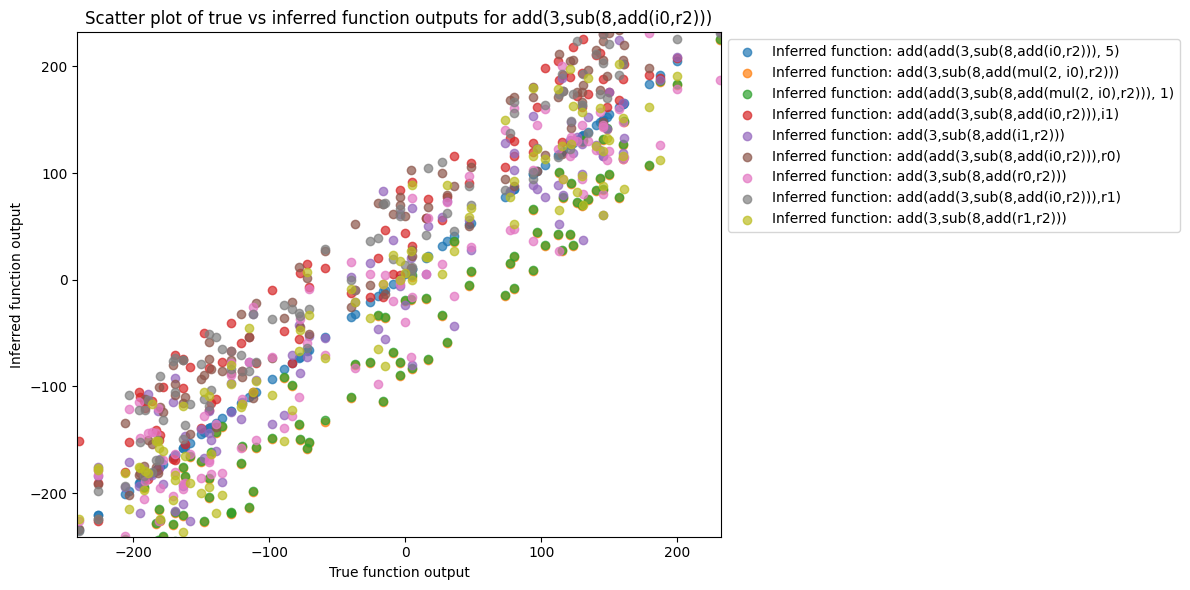

In [11]:
plt.figure(figsize=(12, 6))
for func in fakeFunctions:
    plt.scatter(trueOut, testOuts[func], label=f'Inferred function: {func}', alpha=0.7)
plt.xlabel('True function output')
plt.ylabel('Inferred function output')
plt.xlim(trueOut.min() - 1, trueOut.max() + 1)
plt.ylim(trueOut.min() - 1, trueOut.max() + 1)
plt.title(f'Scatter plot of true vs inferred function outputs for {trueFunction}')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

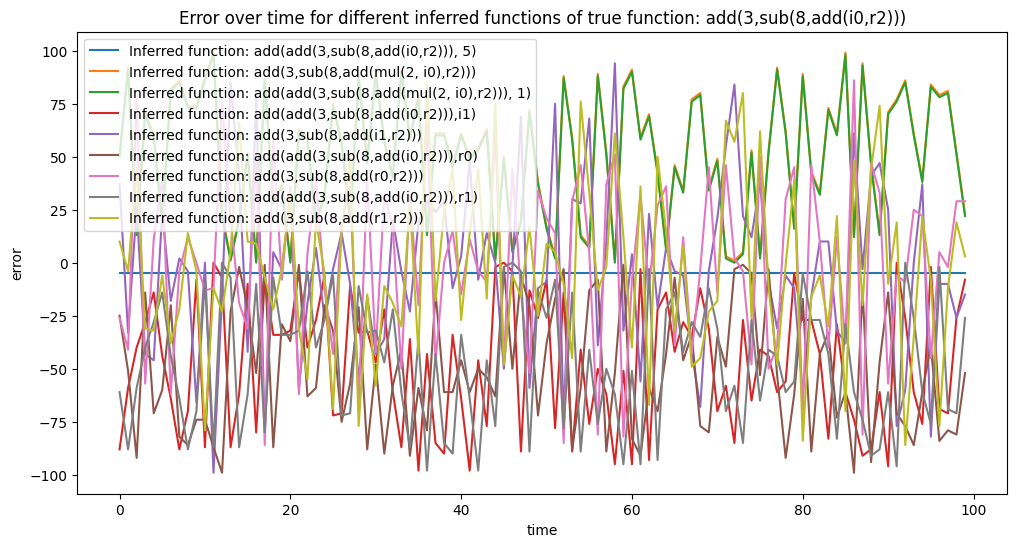

In [12]:
#residual error for each fake function over time
plt.figure(figsize=(12, 6))
for func in fakeFunctions:
    error = trueOut - testOuts[func]
    plt.plot(np.arange(100), error, label=f'Inferred function: {func}')
plt.title(f'Error over time for different inferred functions of true function: {trueFunction}')
plt.xlabel('time')
plt.ylabel('error')
plt.legend()



Inferred function add(add(3,sub(8,add(i0,r2))), 5) has constant error, skipping correlation analysis.


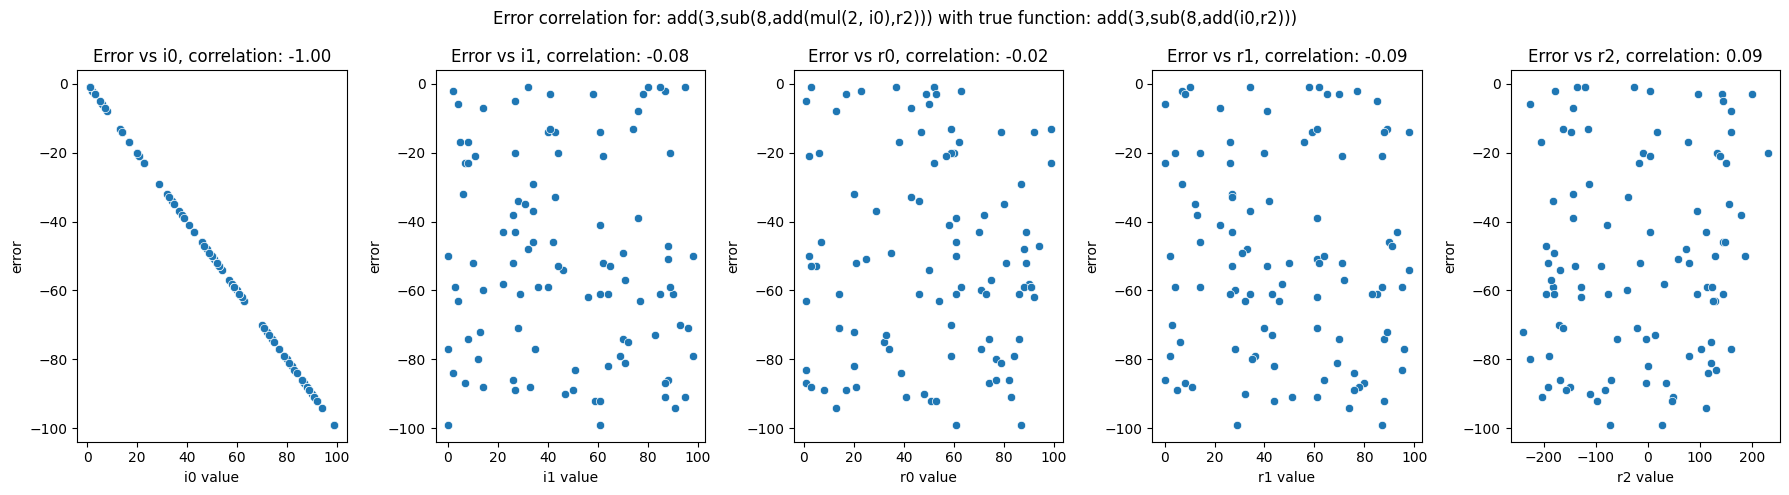

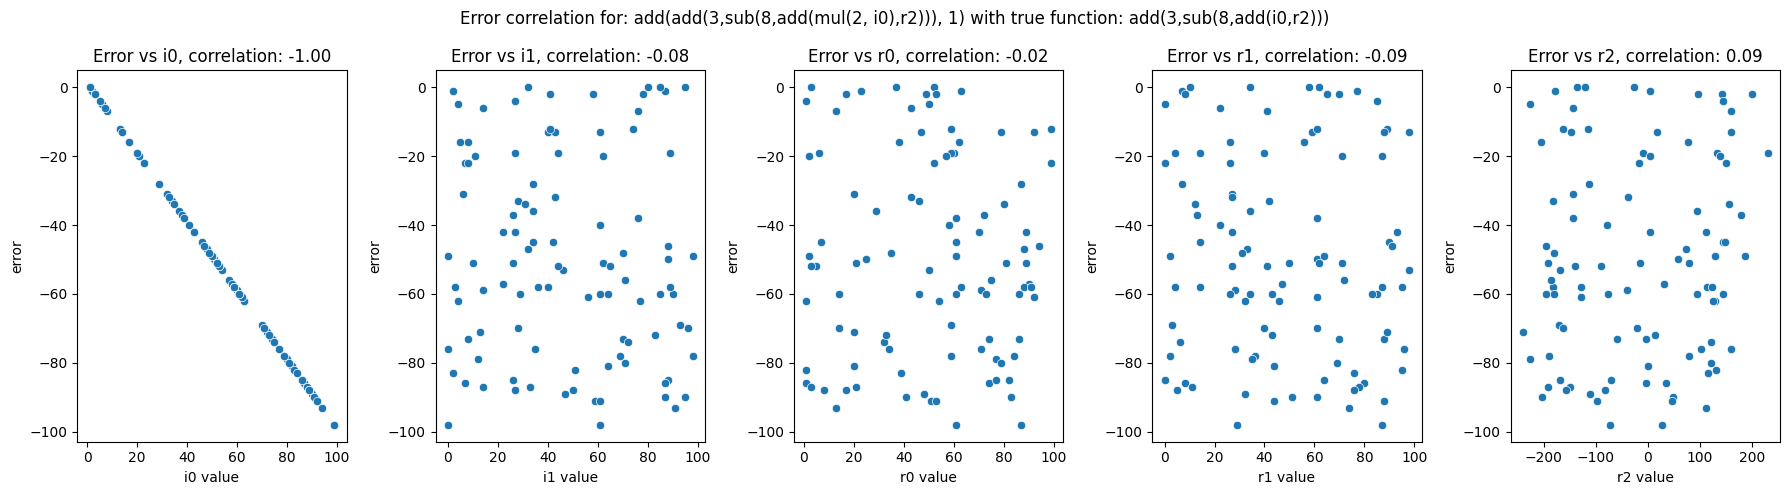

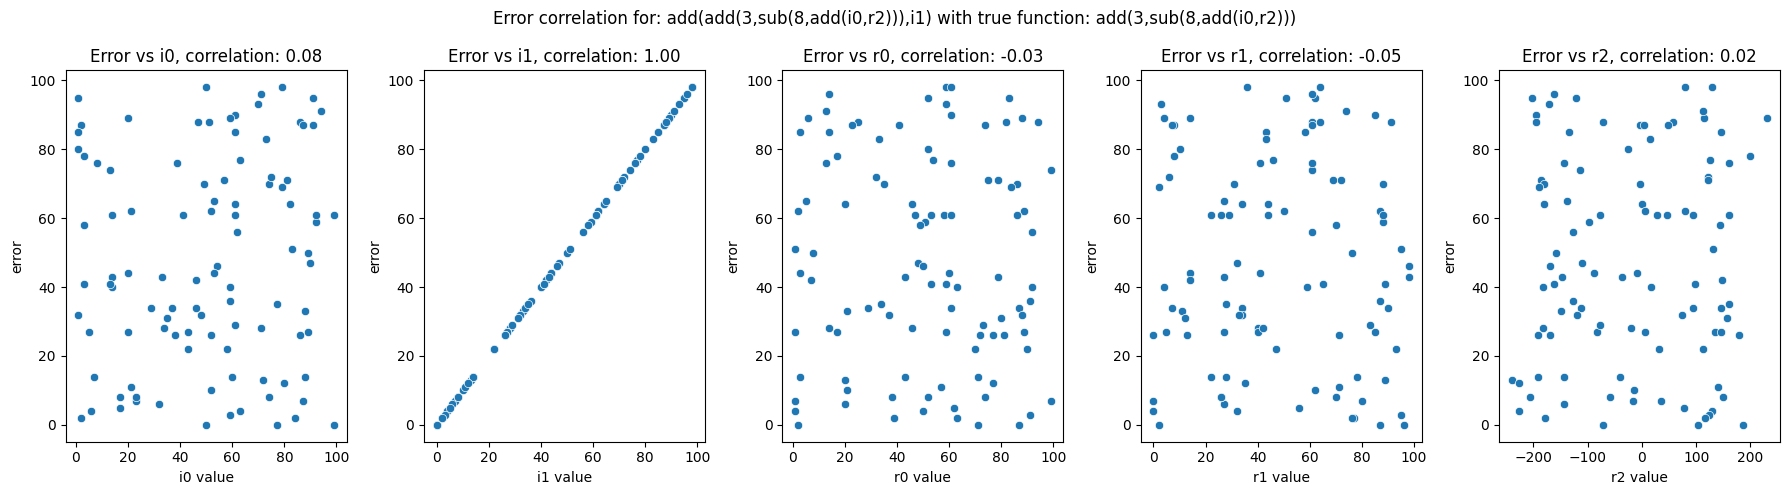

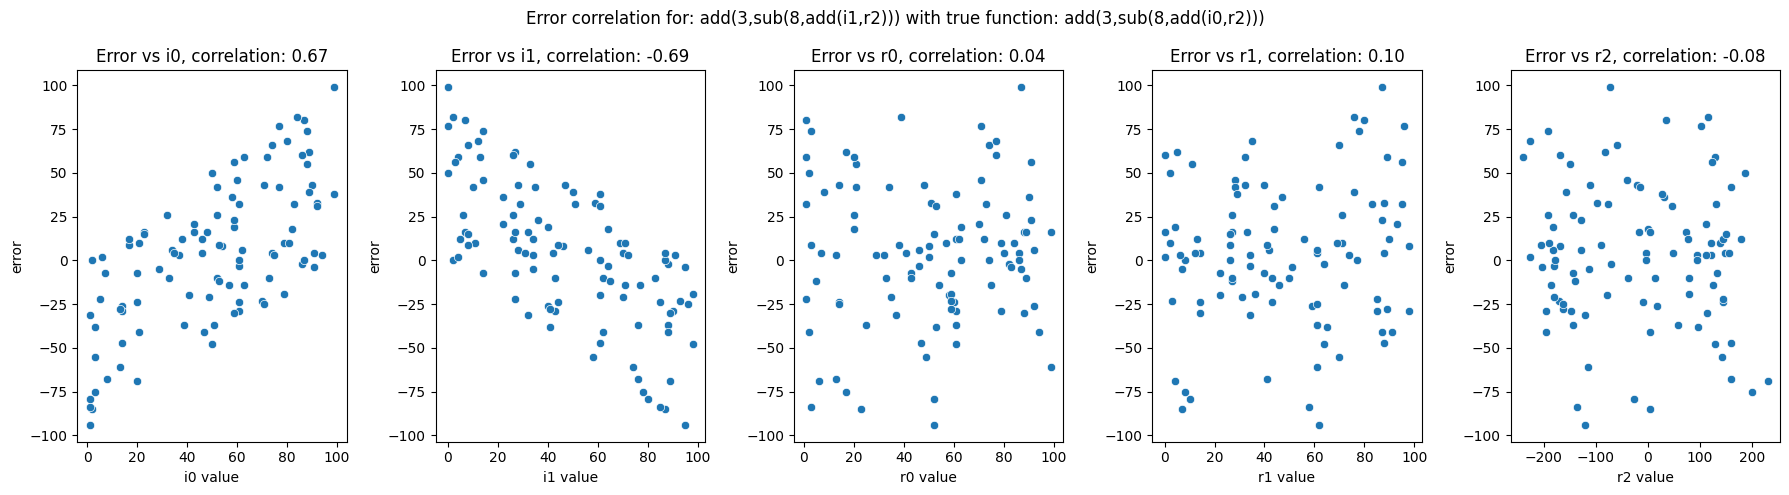

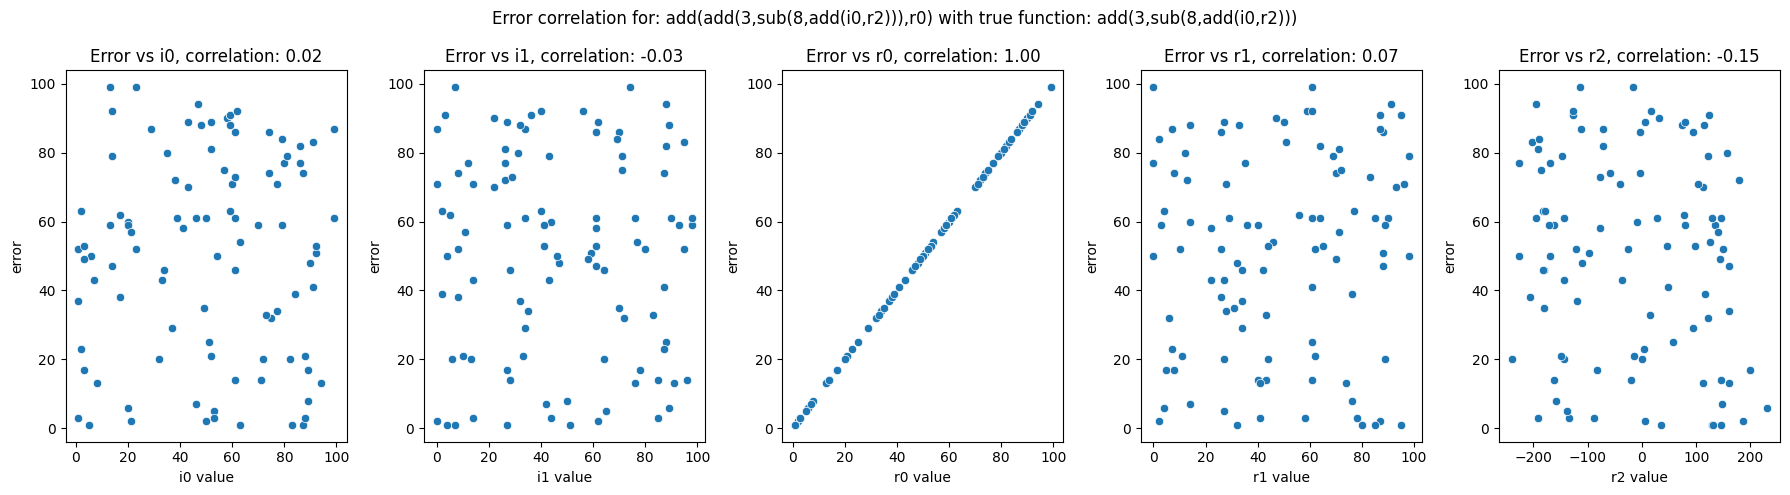

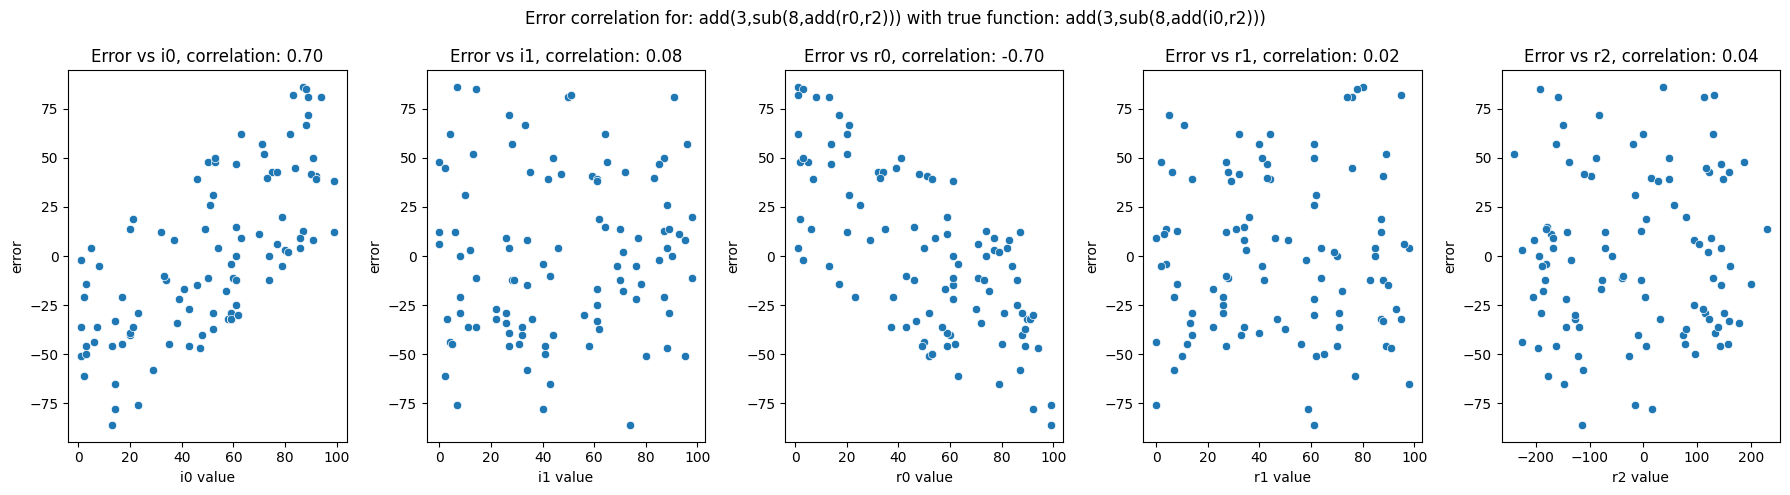

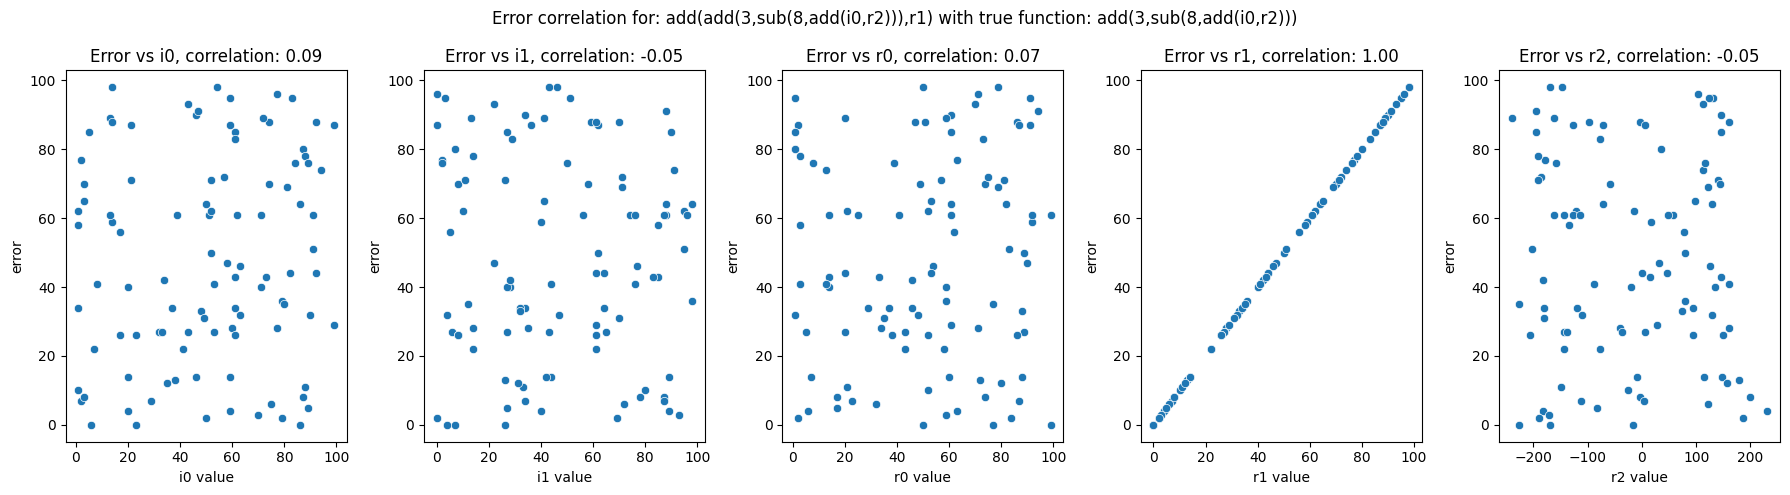

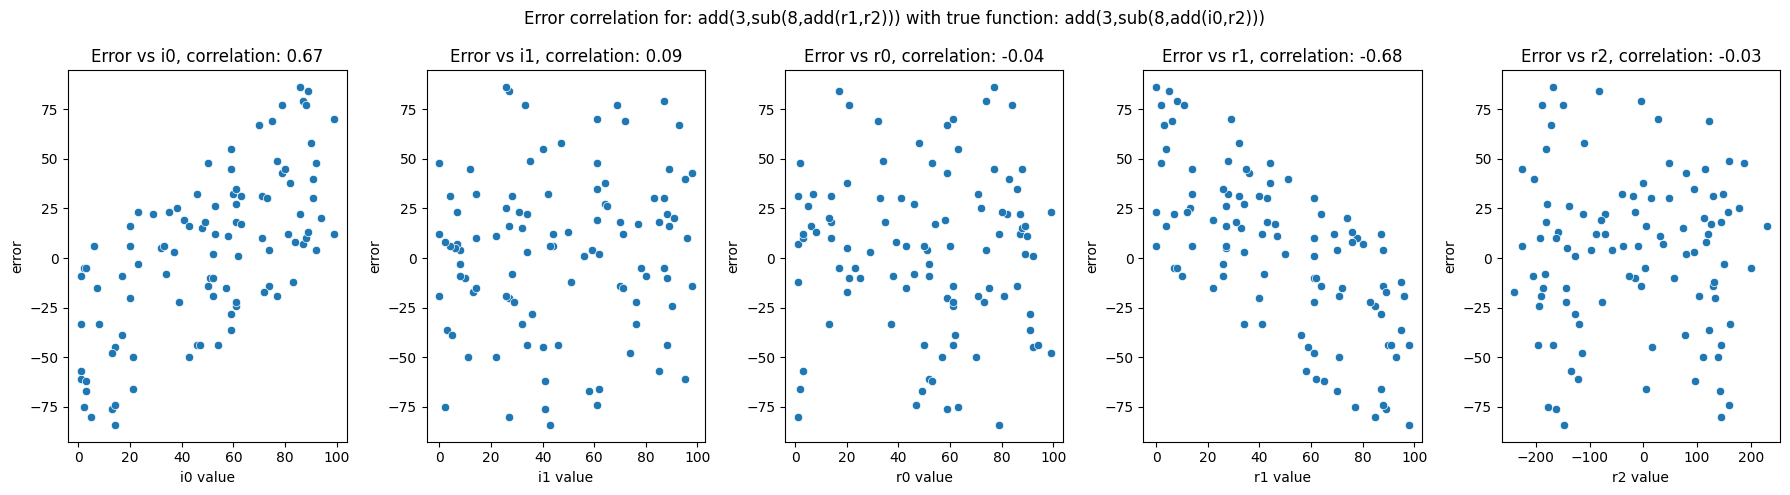

In [13]:
import seaborn as sns

#test of correlation of error with inputs
for func in fakeFunctions:
    error = testOuts[func] - trueOut
    if np.all(error == error[0]):
        print(f'Inferred function {func} has constant error, skipping correlation analysis.')
    else:
        fig, axes = plt.subplots(1, len(testdf.drop(columns=['o']).columns), figsize=(3*len(testdf.columns), 5))
        if len(testdf.drop(columns=['o']).columns) == 1:
            axes = [axes]
        for i, col in enumerate(testdf.drop(columns=['o']).columns):
            sns.scatterplot(x=testdf[col].values, y=error, ax=axes[i])
            axes[i].set_title(f'Error vs {col}, correlation: {np.corrcoef(testdf[col].values, error)[0,1]:.2f}')
            axes[i].set_xlabel(f'{col} value')
            axes[i].set_ylabel('error')
        fig.suptitle(f'Error correlation for: {func} with true function: {trueFunction}')
        plt.tight_layout()
        plt.show()


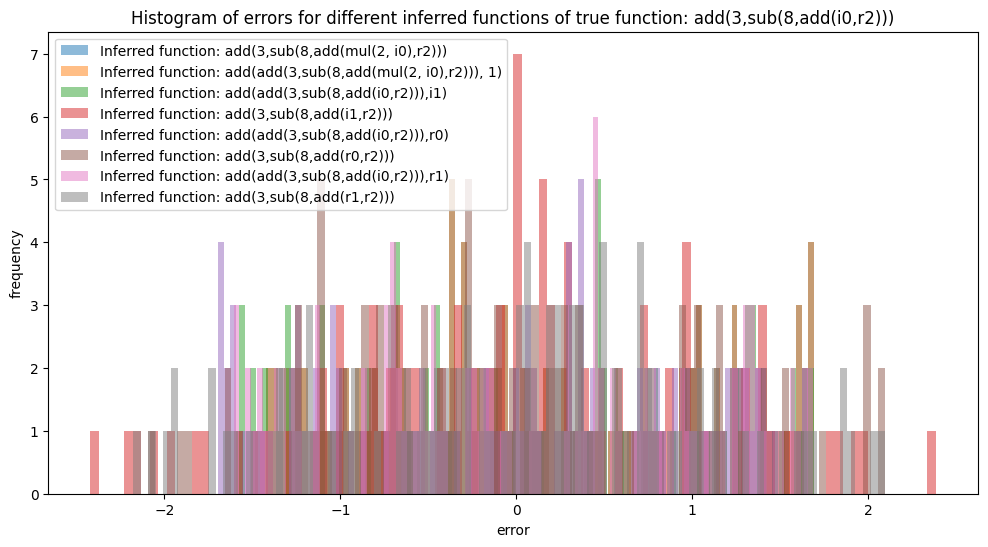

In [14]:
#Histogram of errors for different inferred functions

plt.figure(figsize=(12, 6))
for func in fakeFunctions:
    error = testOuts[func] - trueOut
    error = error - np.mean(error)
    if np.std(error) != 0:
        error = error / np.std(error)
        plt.hist(error, bins=100, alpha=0.5, label=f'Inferred function: {func}')
plt.title(f'Histogram of errors for different inferred functions of true function: {trueFunction}')
plt.xlabel('error')
plt.ylabel('frequency')
plt.legend()
plt.show()
